# **Setup**

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error 

import pickle

# **Data Import**

In [96]:
df = pd.read_csv('rainfall.csv')

print(df.shape)
print(df.columns)
df.head()

(366, 12)
Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')


,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


# **Data Exploration**

## **Info**

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


## **Describe**

In [98]:
df.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


## **Check Missing Values**

In [99]:
df.isna().sum()

day                       0
pressure                  0
maxtemp                   0
temparature               0
mintemp                   0
dewpoint                  0
humidity                  0
cloud                     0
rainfall                  0
sunshine                  0
         winddirection    1
windspeed                 1
dtype: int64

# **Data Cleaning**

## **Drop Day Column**

In [100]:
print('Dataframe Shape Before Drop:', df.shape)

# Drop Columns 
df.drop(['day'],axis=1,inplace=True)
print('Dataframe Shape After Drop:', df.shape)

Dataframe Shape Before Drop: (366, 12)
Dataframe Shape After Drop: (366, 11)


## **Trim Column Names**

In [101]:
# Trim Column Names 
print('Column Names Before Trim:', df.columns)
print('\n')

# Clean Column Names
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')
print('Column Names After Trim:', df.columns)

Column Names Before Trim: Index(['pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')


Column Names After Trim: Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')


## **Missing Values**

In [102]:
print(df['winddirection'].unique())
print(df['winddirection'].mode()[0])

[ 80.  50.  40.  20.  30.  60.  70.  10. 200. 220. 120. 190. 210. 300.
 240. 180. 230.  90. 170. 150. 100. 130.  nan 160. 270. 280. 250. 260.
 290. 350. 110. 140.]
20.0


In [103]:
df['winddirection'] = df['winddirection'].fillna(df['winddirection'].mode()[0])
df['windspeed'] = df['windspeed'].fillna(df['windspeed'].mean())

df.isna().sum()

pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

## **Encode Target Variable**

In [104]:
# Encode Categorical Variables
df['rainfall'] = df['rainfall'].map({'yes': 1, 'no': 0})
df['rainfall']

0      1
1      1
2      1
3      1
4      1
      ..
361    1
362    1
363    1
364    1
365    0
Name: rainfall, Length: 366, dtype: int64

# **Data Exploration**

## **Heatmap**

<Axes: >

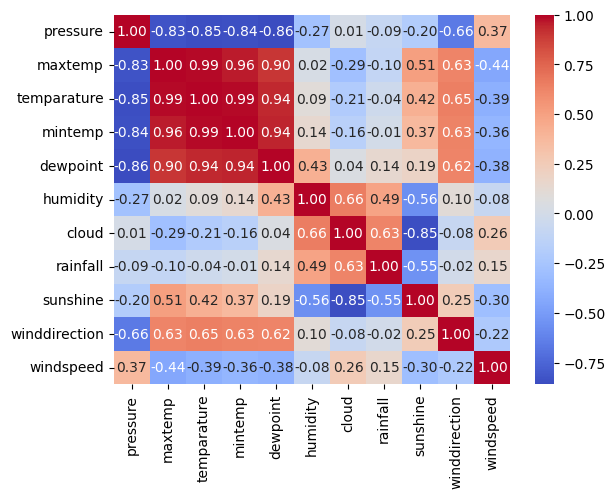

In [105]:
import seaborn as sns

sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm')

## **Pairplot**

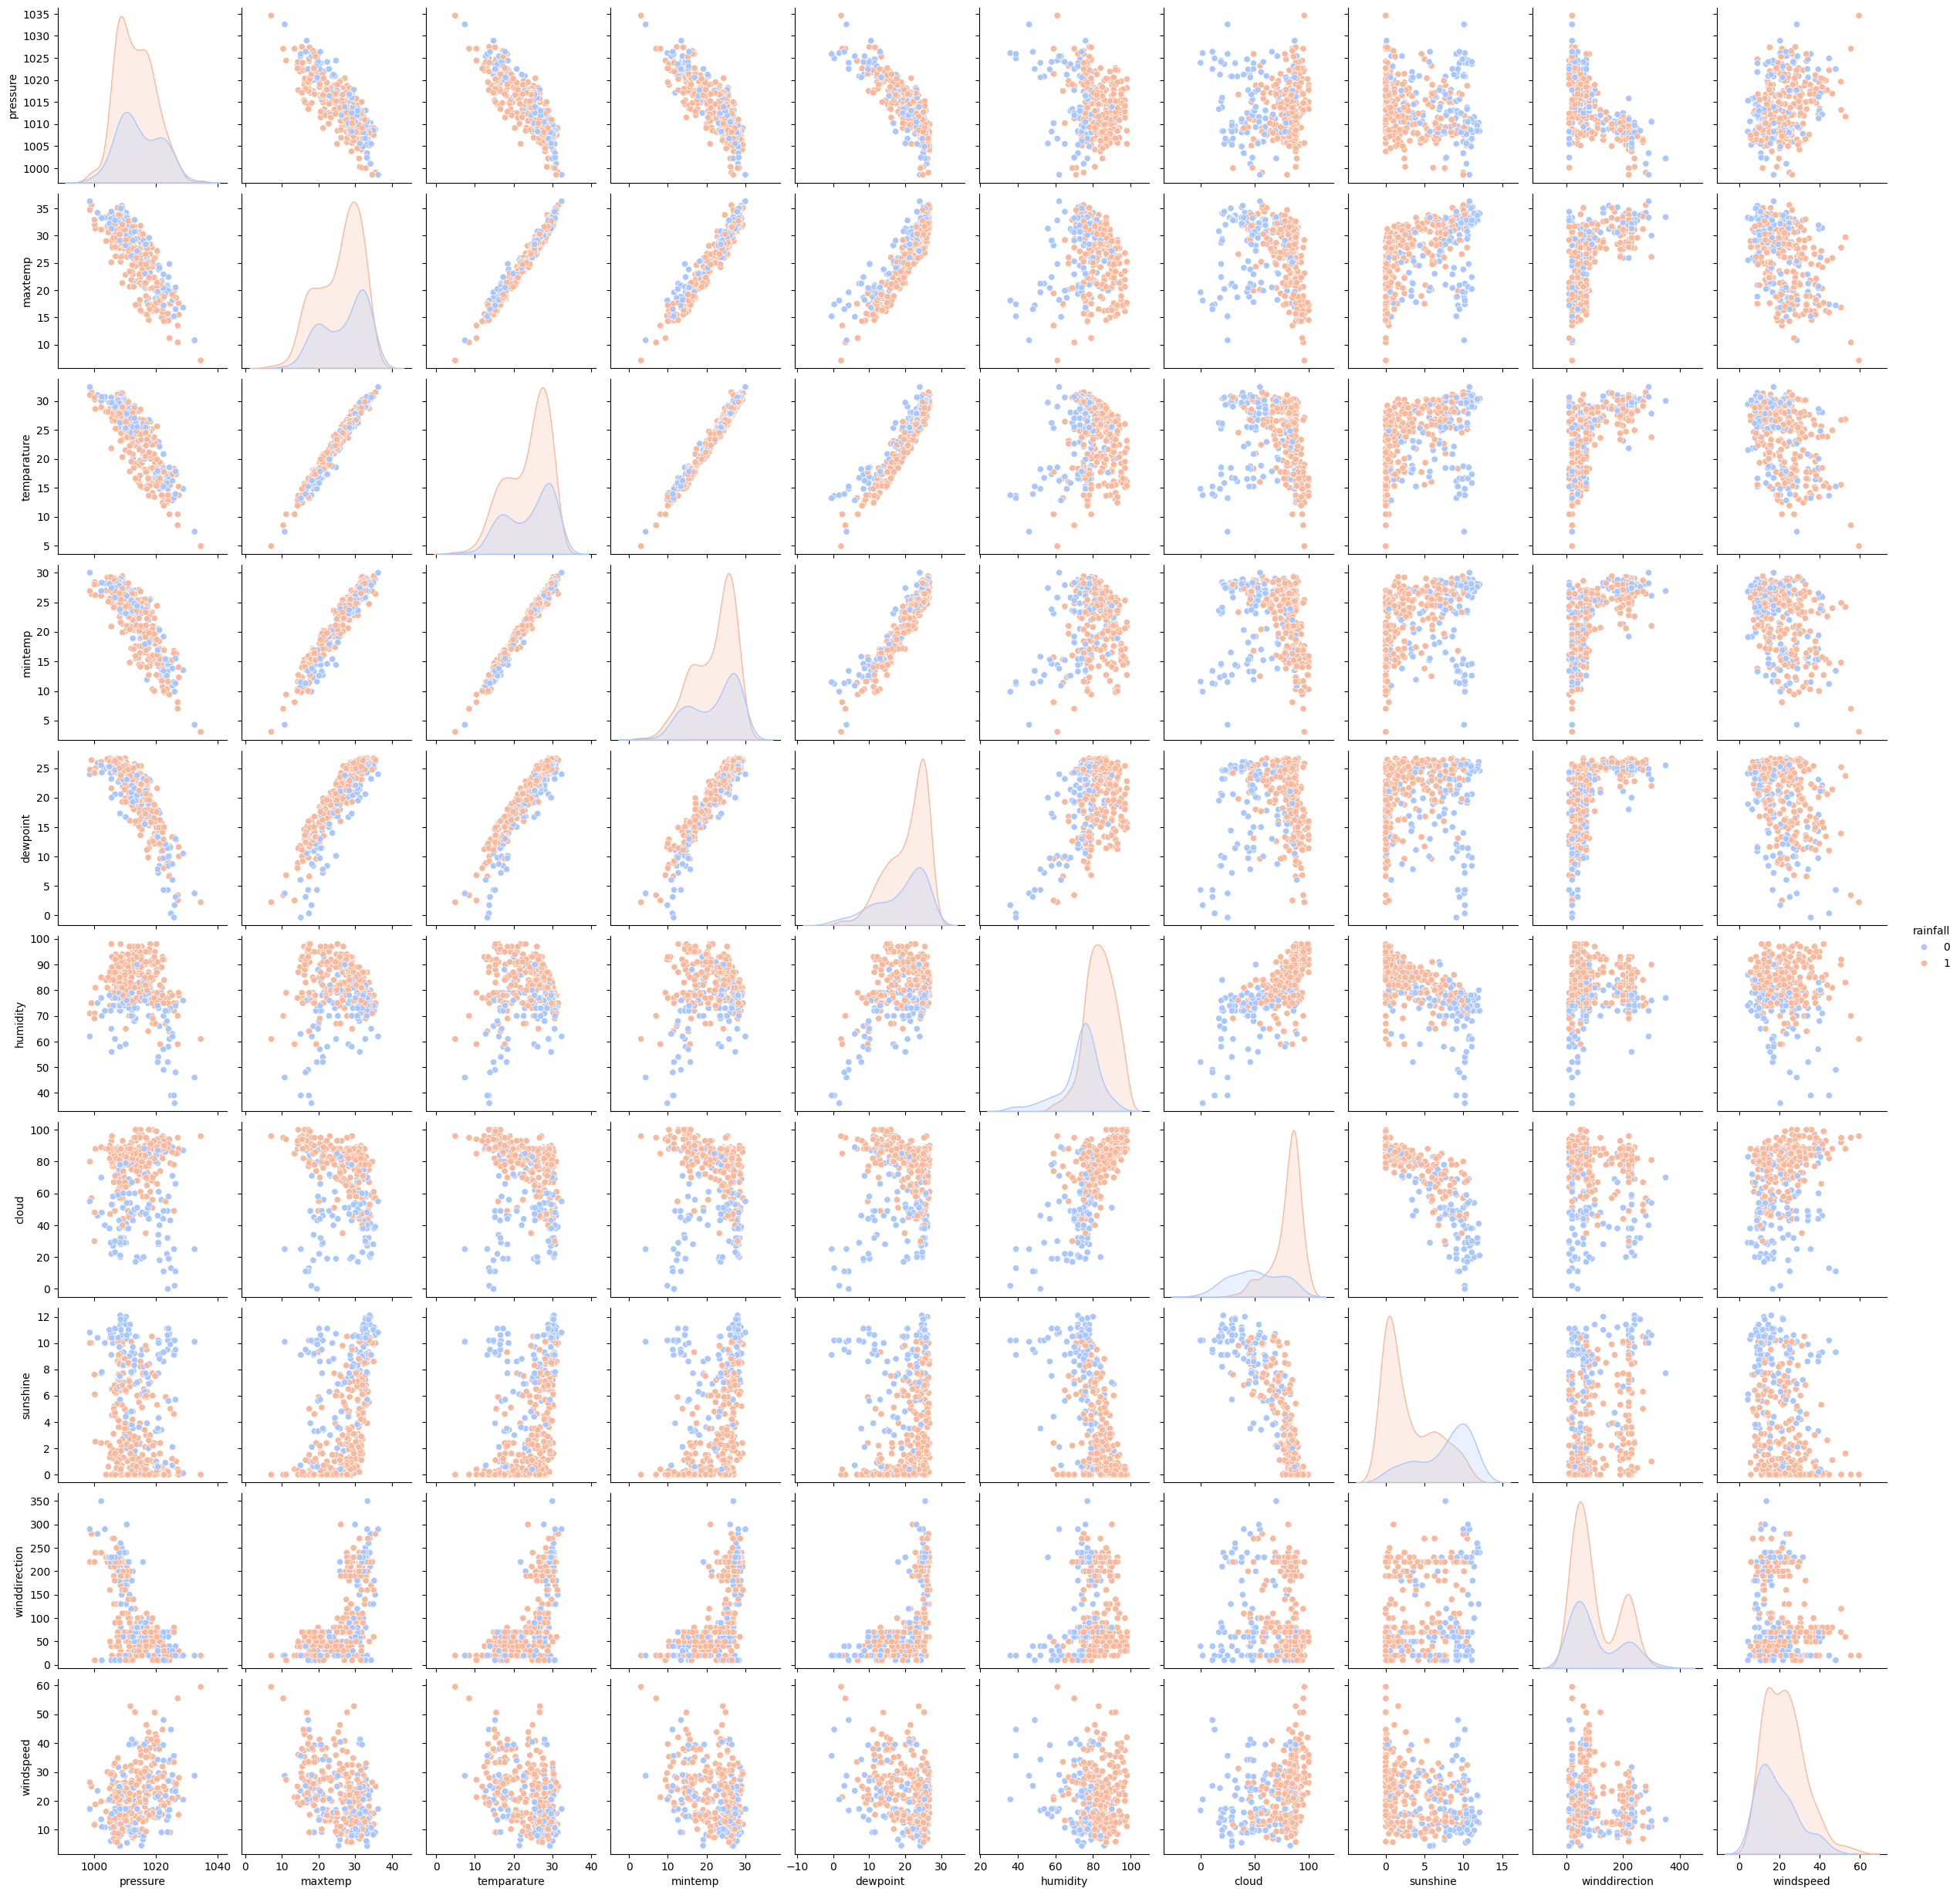

In [106]:
sns.pairplot(df, hue='rainfall', diag_kind='kde', palette='coolwarm')

## **Histogram Plot**

In [107]:
df.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

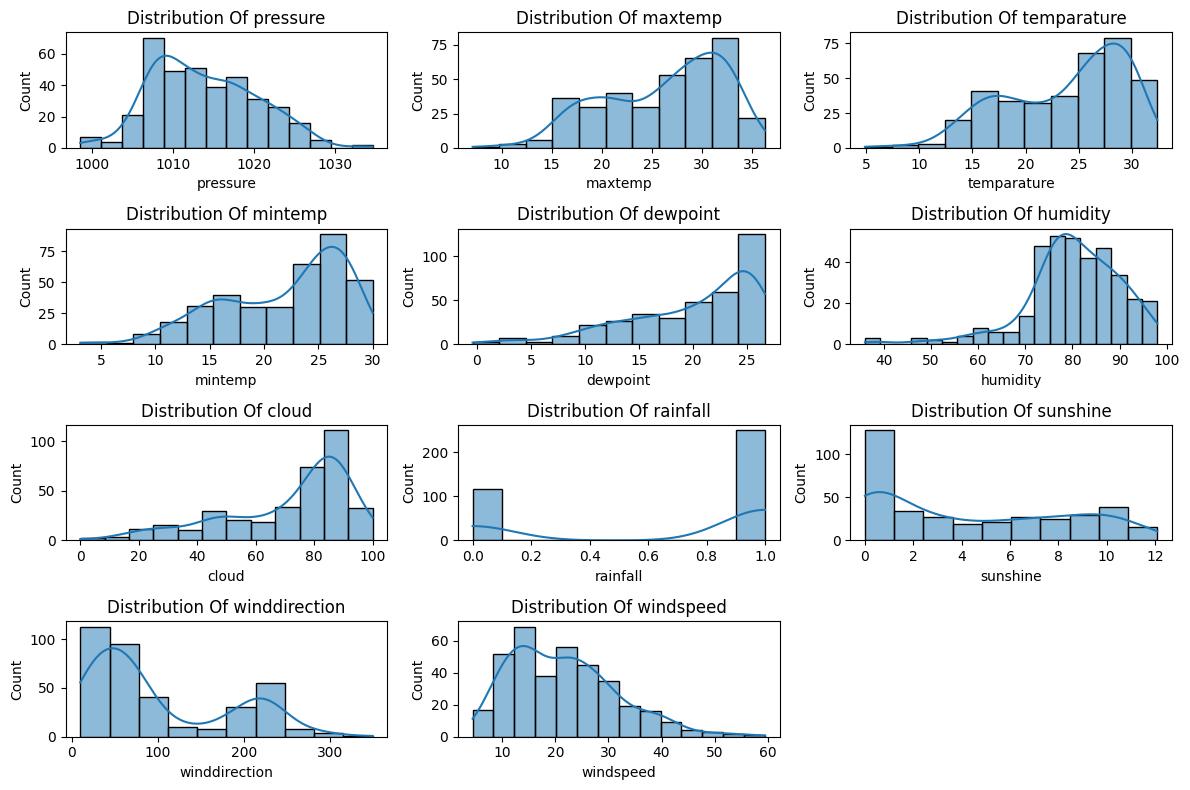

In [108]:
plt.figure(figsize=(12,8))

for i, col in enumerate(df.select_dtypes('number').columns, start=1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution Of {col}')
    plt.tight_layout()

## **Count Plot**

In [109]:
df['rainfall'].value_counts()

rainfall
1    249
0    117
Name: count, dtype: int64

Text(0.5, 1.0, 'Count Plot Of Rainfall')

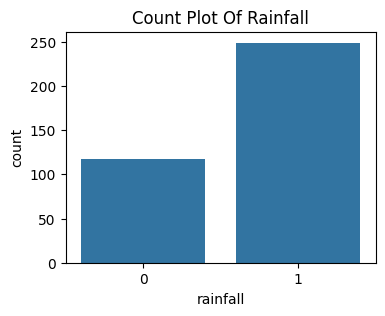

In [110]:
# Count Plot 
plt.figure(figsize=(4,3))
sns.countplot(x='rainfall', data=df)
plt.title('Count Plot Of Rainfall')

# **Data Pre Processing**

## **Remove Correlated Columns**

In [111]:
df.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

In [112]:
# Drop Correlated Columns Based On Heatmap
print('Dataframe Shape Before Drop:', df.shape)
df.drop(['maxtemp','mintemp','dewpoint'],axis=1,inplace=True)
print('Dataframe Shape After Drop:', df.shape)

Dataframe Shape Before Drop: (366, 11)
Dataframe Shape After Drop: (366, 8)


## **Data Imbalance**

In [113]:
df.head()

,pressure,temparature,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,18.3,72,49,1,9.3,80.0,26.3
1,1022.0,18.9,81,83,1,0.6,50.0,15.3
2,1019.7,19.3,95,91,1,0.0,40.0,14.2
3,1018.9,20.6,90,88,1,1.0,50.0,16.9
4,1015.9,20.7,95,81,1,0.0,40.0,13.7


In [116]:
df['rainfall'].value_counts()

rainfall
1    249
0    117
Name: count, dtype: int64

In [124]:
# No Rainfall Records Over Sampling
df_rainfall_0 = df[df['rainfall']==0].sample(n=249,random_state=0,replace=True)
df_rainfall_0.head()

,pressure,temparature,humidity,cloud,rainfall,sunshine,winddirection,windspeed
153,1006.0,30.3,79,58,0,10.0,230.0,27.4
173,1009.5,30.5,75,32,0,9.3,220.0,10.9
218,1005.3,30.1,72,29,0,10.6,220.0,6.1
231,1007.7,30.1,77,59,0,10.4,230.0,16.6
231,1007.7,30.1,77,59,0,10.4,230.0,16.6


In [126]:
# Combine Dataframes
df_rainfall_1 = df[df['rainfall']==1]

# Combine Dataframes
df = pd.concat([df_rainfall_0, df_rainfall_1], axis=0, ignore_index=True)
df = df.sample(frac=1, random_state=0).reset_index(drop=True)

# Check Class Distribution
df['rainfall'].value_counts()

rainfall
0    249
1    249
Name: count, dtype: int64

## **Feature-Target Split**

In [127]:
X = df.drop(['rainfall'], axis=1)
y = df['rainfall']

print('X Shape:', X.shape)
print('y Shape:', y.shape)

X Shape: (498, 7)
y Shape: (498,)


## **Train-Test Split**

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print('Train Data Shape:', X_train.shape, y_train.shape)
print('Test Data Shape:', X_test.shape, y_test.shape)

Train Data Shape: (398, 7) (398,)
Test Data Shape: (100, 7) (100,)


# **Model**

## **Create Model**

In [140]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

model = RandomForestClassifier(random_state=0, n_jobs=-1)

# Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10, 20,30,40],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

model_tuning = RandomizedSearchCV(model, param_distributions=param_grid, n_iter=10, cv=3, verbose=2, random_state=0, n_jobs=-1)
model_tuning.fit(X_train, y_train)

# Best Parameters
print('Best Parameters:', model_tuning.best_params_)
model_best = model_tuning.best_estimator_

y_pred = model_best.predict(X_test)

# Evaluate Model Performance
print('Train Score:', model_best.score(X_train, y_train))
print('Test Score:', model_best.score(X_test, y_test))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Train Score: 1.0
Test Score: 0.89


## **Model Evaluation**

In [134]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.86      0.91      0.89        47
           1       0.92      0.87      0.89        53

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100



array([[43,  4],
       [ 7, 46]])

## **Cross-Validation Score**

In [142]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model_best, X_train, y_train, cv=5)

print('Cross Validation Scores:', cv_scores)
print('Mean Cross Validation Score:', cv_scores.mean())

# Save Model
with open('rainfall_model.pkl', 'wb') as file:
    pickle.dump(model_best, file)

Cross Validation Scores: [0.875      0.875      0.85       0.89873418 0.84810127]
Mean Cross Validation Score: 0.8693670886075949


# **Import & Use Model**

In [143]:
import pickle 

# Load Model
with open('rainfall_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Make Predictions
sample_data = X_test.sample(5, random_state=0)
predictions = loaded_model.predict(sample_data)
# print('Sample Data:', sample_data)
print('Predictions:', predictions)

Predictions: [1 0 0 0 0]


In [144]:
loaded_model.__dir__()

['estimator',
 'n_estimators',
 'estimator_params',
 'bootstrap',
 'oob_score',
 'n_jobs',
 'random_state',
 'verbose',
 'warm_start',
 'class_weight',
 'max_samples',
 'criterion',
 'max_depth',
 'min_samples_split',
 'min_samples_leaf',
 'min_weight_fraction_leaf',
 'max_features',
 'max_leaf_nodes',
 'min_impurity_decrease',
 'monotonic_cst',
 'ccp_alpha',
 'feature_names_in_',
 'n_features_in_',
 '_n_samples',
 'n_outputs_',
 'classes_',
 'n_classes_',
 '_n_samples_bootstrap',
 'estimator_',
 'estimators_',
 '__module__',
 '__firstlineno__',
 '__annotations__',
 '__doc__',
 '_parameter_constraints',
 '__init__',
 '__static_attributes__',
 'set_fit_request',
 'set_score_request',
 '__abstractmethods__',
 '_abc_impl',
 '__slotnames__',
 '_get_oob_predictions',
 '_set_oob_score_and_attributes',
 '_validate_y_class_weight',
 'predict',
 'predict_proba',
 'predict_log_proba',
 '__sklearn_tags__',
 '_estimator_type',
 'score',
 '__dict__',
 '__weakref__',
 '__new__',
 '__repr__',
 '__has

In [146]:
loaded_model.feature_names_in_

array(['pressure', 'temparature', 'humidity', 'cloud', 'sunshine',
       'winddirection', 'windspeed'], dtype=object)

# **References**

* https://www.youtube.com/watch?v=Pn5NTfeKJzY